In [1]:
import mapie
print(f"MAPIE version: {mapie.__version__}")

MAPIE version: 1.4.0


In [3]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# MAPIE 1.x API for conformal prediction
from mapie.regression import SplitConformalRegressor, ConformalizedQuantileRegressor
from mapie.metrics.regression import regression_coverage_score

# Display config
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded.")
print(f"MAPIE version: {mapie.__version__ if 'mapie' in dir() else 'imported as submodules'}")

Imports loaded.
MAPIE version: 1.4.0


In [5]:
# Reload raw data
df = pd.read_csv("../data/raw/Debutanizer_Data.txt", sep=r'\s+')

# Rebuild lagged features (same scheme as end of week 2)
X_cols = ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7']
y_col = 'y'
LAGS = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]

def add_lags(df, cols, lags):
    out = df.copy()
    for col in cols:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out[col].shift(lag)
    return out

df_lagged = add_lags(df, X_cols, LAGS).dropna().reset_index(drop=True)
X_cols_lagged = [c for c in df_lagged.columns if c != 'y']

print(f"Lagged data shape: {df_lagged.shape}")
print(f"Number of features: {len(X_cols_lagged)}")

Lagged data shape: (2364, 78)
Number of features: 77


In [6]:
print(f"df_lagged shape: {df_lagged.shape}")
print(f"Features: {len(X_cols_lagged)}")

df_lagged shape: (2364, 78)
Features: 77


In [7]:
# Three-way chronological split: 60% train, 20% calibration, 20% test
n = len(df_lagged)
train_end = int(n * 0.60)
cal_end   = int(n * 0.80)
# Test = remainder

train_df = df_lagged.iloc[:train_end].copy()
cal_df   = df_lagged.iloc[train_end:cal_end].copy()
test_df  = df_lagged.iloc[cal_end:].copy()

print(f"Total samples:        {n}")
print(f"Train:        {len(train_df):4d} samples  (index    0 .. {train_end-1})")
print(f"Calibration:  {len(cal_df):4d} samples  (index {train_end} .. {cal_end-1})")
print(f"Test:         {len(test_df):4d} samples  (index {cal_end} .. {n-1})")
print(f"\nTotal:                {len(train_df)+len(cal_df)+len(test_df)}  (should equal {n})")

Total samples:        2364
Train:        1418 samples  (index    0 .. 1417)
Calibration:   473 samples  (index 1418 .. 1890)
Test:          473 samples  (index 1891 .. 2363)

Total:                2364  (should equal 2364)


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[X_cols_lagged])
X_cal   = scaler.transform(cal_df[X_cols_lagged])
X_test  = scaler.transform(test_df[X_cols_lagged])

y_train = train_df[y_col].values
y_cal   = cal_df[y_col].values
y_test  = test_df[y_col].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_cal:   {X_cal.shape}, y_cal:   {y_cal.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (1418, 77), y_train: (1418,)
X_cal:   (473, 77), y_cal:   (473,)
X_test:  (473, 77), y_test:  (473,)


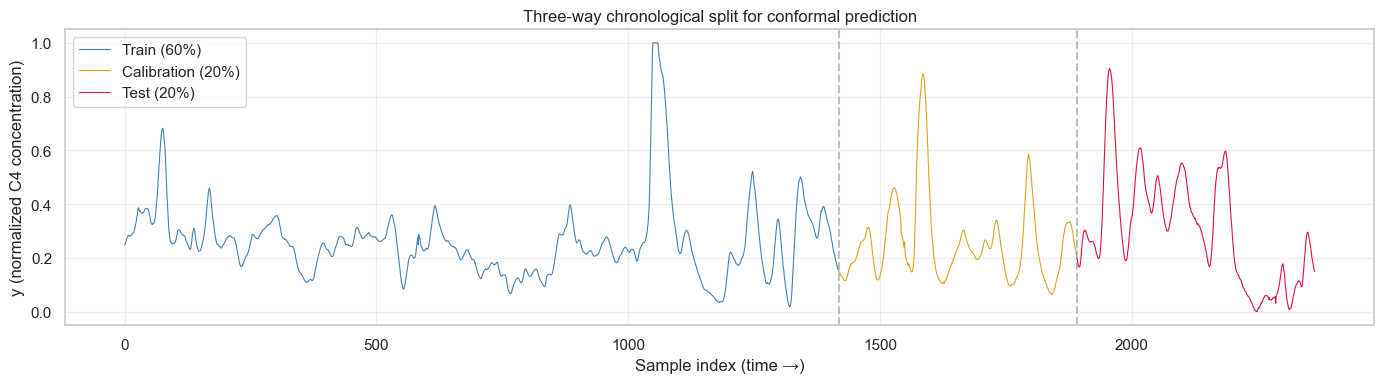

          train      cal     test
count  1418.000  473.000  473.000
mean      0.262    0.258    0.301
std       0.142    0.157    0.203
min       0.019    0.065    0.000
25%       0.185    0.149    0.123
50%       0.249    0.225    0.287
75%       0.299    0.303    0.444
max       1.000    0.884    0.904


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df.index, train_df['y'], color='steelblue', linewidth=0.8, label='Train (60%)')
ax.plot(cal_df.index,   cal_df['y'],   color='goldenrod', linewidth=0.8, label='Calibration (20%)')
ax.plot(test_df.index,  test_df['y'],  color='crimson',   linewidth=0.8, label='Test (20%)')
ax.axvline(train_end, color='gray', linestyle='--', alpha=0.5)
ax.axvline(cal_end,   color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title("Three-way chronological split for conformal prediction")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution check
summary = pd.DataFrame({
    'train': train_df[y_col].describe(),
    'cal':   cal_df[y_col].describe(),
    'test':  test_df[y_col].describe(),
})
print(summary.round(3))

In [10]:
# Same hyperparameters that won week 2's CV grid search
final_params = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'min_child_weight': 10,
    'n_estimators': 13,
}

xgb_model = xgb.XGBRegressor(
    **final_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train)

# Quick sanity check: predict on each split and report metrics
def quick_metrics(y_true, y_pred, label):
    return {
        'split': label,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

results = pd.DataFrame([
    quick_metrics(y_train, xgb_model.predict(X_train), 'train (fit)'),
    quick_metrics(y_cal,   xgb_model.predict(X_cal),   'calibration (held out)'),
    quick_metrics(y_test,  xgb_model.predict(X_test),  'test (held out)'),
])
print("=== XGBoost point predictions on the 60/20/20 split ===")
print(results.round(4))

=== XGBoost point predictions on the 60/20/20 split ===
                    split    RMSE     MAE      R2
0             train (fit)  0.0633  0.0454  0.7998
1  calibration (held out)  0.1025  0.0739  0.5738
2         test (held out)  0.1487  0.1167  0.4645


In [11]:
# Wrap the trained XGBoost in a SplitConformalRegressor
mapie_split = SplitConformalRegressor(
    estimator=xgb_model,
    confidence_level=0.95,
    prefit=True,         # XGBoost is already trained — skip fitting
)

# Conformalize on the calibration set
mapie_split.conformalize(X_cal, y_cal)

# Predict intervals on the test set
y_pred_split, y_pis_split = mapie_split.predict_interval(X_test)

# y_pis has shape (n_samples, 2, n_confidence_levels) — squeeze the last dim
y_lower_split = y_pis_split[:, 0, 0]
y_upper_split = y_pis_split[:, 1, 0]

print(f"Point predictions shape: {y_pred_split.shape}")
print(f"Interval shape:          {y_pis_split.shape}")
print(f"  → y_lower: {y_lower_split.shape}, y_upper: {y_upper_split.shape}")

# First 5 predictions, just to inspect
print("\nFirst 5 test predictions with intervals:")
for i in range(5):
    print(f"  y_true={y_test[i]:.3f}  pred={y_pred_split[i]:.3f}  "
          f"interval=[{y_lower_split[i]:.3f}, {y_upper_split[i]:.3f}]")

Point predictions shape: (473,)
Interval shape:          (473, 2, 1)
  → y_lower: (473,), y_upper: (473,)

First 5 test predictions with intervals:
  y_true=0.200  pred=0.308  interval=[0.072, 0.544]
  y_true=0.192  pred=0.308  interval=[0.072, 0.544]
  y_true=0.180  pred=0.308  interval=[0.072, 0.544]
  y_true=0.172  pred=0.298  interval=[0.063, 0.534]
  y_true=0.167  pred=0.295  interval=[0.059, 0.531]


In [12]:
# Interval widths should all be identical for split conformal
widths_split = y_upper_split - y_lower_split
print(f"Split conformal interval width:")
print(f"  min:  {widths_split.min():.4f}")
print(f"  max:  {widths_split.max():.4f}")
print(f"  mean: {widths_split.mean():.4f}")
print(f"  std:  {widths_split.std():.6f}   ← should be ~0 (constant-width)")
print(f"  → Every interval is ±{widths_split.mean()/2:.4f} around the point prediction")

# Empirical coverage: fraction of y_test values inside [y_lower, y_upper]
coverage = np.mean((y_test >= y_lower_split) & (y_test <= y_upper_split))
print(f"\n=== Empirical coverage on test set ===")
print(f"Nominal coverage:   95.00%")
print(f"Empirical coverage: {coverage*100:.2f}%")
print(f"Gap from nominal:   {(coverage - 0.95)*100:+.2f} percentage points")

# Also using MAPIE's built-in coverage metric for cross-check
mapie_coverage = regression_coverage_score(y_test, y_pis_split)[0]
print(f"MAPIE coverage score (cross-check): {mapie_coverage*100:.2f}%")

Split conformal interval width:
  min:  0.4718
  max:  0.4718
  mean: 0.4718
  std:  0.000000   ← should be ~0 (constant-width)
  → Every interval is ±0.2359 around the point prediction

=== Empirical coverage on test set ===
Nominal coverage:   95.00%
Empirical coverage: 93.23%
Gap from nominal:   -1.77 percentage points
MAPIE coverage score (cross-check): 93.23%


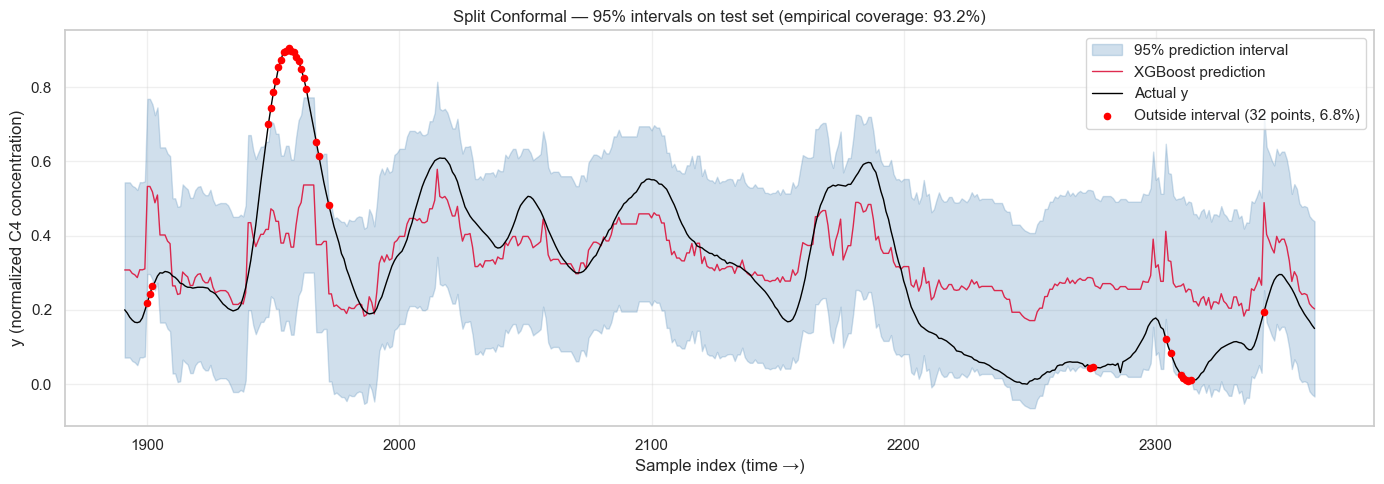

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

# Confidence band
ax.fill_between(
    test_df.index, y_lower_split, y_upper_split,
    color='steelblue', alpha=0.25, label='95% prediction interval'
)

# Point predictions
ax.plot(test_df.index, y_pred_split, color='crimson', linewidth=1.0, label='XGBoost prediction', alpha=0.9)

# Actual values
ax.plot(test_df.index, y_test, color='black', linewidth=1.0, label='Actual y')

# Mark points outside the interval — these are coverage failures
miss_mask = (y_test < y_lower_split) | (y_test > y_upper_split)
ax.scatter(
    test_df.index[miss_mask], y_test[miss_mask],
    color='red', s=20, zorder=5,
    label=f'Outside interval ({miss_mask.sum()} points, {miss_mask.mean()*100:.1f}%)'
)

ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"Split Conformal — 95% intervals on test set (empirical coverage: {coverage*100:.1f}%)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Two quantile XGBoost models for the 2.5% and 97.5% quantiles → 95% central interval
quantile_alpha = 0.05  # → lower 0.025, upper 0.975

# Lower-quantile model
xgb_lower = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=quantile_alpha / 2,         # 0.025
    **{k: v for k, v in final_params.items() if k != 'objective'},
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_lower.fit(X_train, y_train)

# Upper-quantile model
xgb_upper = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=1 - quantile_alpha / 2,     # 0.975
    **{k: v for k, v in final_params.items() if k != 'objective'},
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_upper.fit(X_train, y_train)

# Median model — point predictions
xgb_median = xgb.XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.5,
    **{k: v for k, v in final_params.items() if k != 'objective'},
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_median.fit(X_train, y_train)

# Predict raw (un-conformalized) quantile intervals on test
y_pred_lower_raw  = xgb_lower.predict(X_test)
y_pred_upper_raw  = xgb_upper.predict(X_test)
y_pred_median     = xgb_median.predict(X_test)

# Measure raw quantile coverage on test (before conformal calibration)
raw_coverage = np.mean((y_test >= y_pred_lower_raw) & (y_test <= y_pred_upper_raw))
raw_mean_width = (y_pred_upper_raw - y_pred_lower_raw).mean()

print(f"=== RAW quantile regression (no conformal calibration) ===")
print(f"  Empirical coverage: {raw_coverage*100:.2f}%  (target 95%)")
print(f"  Mean interval width: {raw_mean_width:.4f}")
print(f"\n=== Split conformal (for comparison) ===")
print(f"  Empirical coverage: {coverage*100:.2f}%")
print(f"  Mean interval width: {widths_split.mean():.4f}")

=== RAW quantile regression (no conformal calibration) ===
  Empirical coverage: 76.74%  (target 95%)
  Mean interval width: 0.4547

=== Split conformal (for comparison) ===
  Empirical coverage: 93.23%
  Mean interval width: 0.4718


In [15]:
# MAPIE's ConformalizedQuantileRegressor corrects the raw quantile model's miscalibration
# We provide a list of three estimators: [lower, median, upper]
mapie_cqr = ConformalizedQuantileRegressor(
    estimator=[xgb_lower, xgb_median, xgb_upper],
    confidence_level=0.95,
    prefit=True,
)

mapie_cqr.conformalize(X_cal, y_cal)

y_pred_cqr, y_pis_cqr = mapie_cqr.predict_interval(X_test)
y_lower_cqr = y_pis_cqr[:, 0, 0]
y_upper_cqr = y_pis_cqr[:, 1, 0]

widths_cqr = y_upper_cqr - y_lower_cqr
coverage_cqr = np.mean((y_test >= y_lower_cqr) & (y_test <= y_upper_cqr))

print(f"=== Conformalized Quantile Regression (CQR) ===")
print(f"  Empirical coverage: {coverage_cqr*100:.2f}%  (target 95%)")
print(f"  Width — min:  {widths_cqr.min():.4f}")
print(f"  Width — mean: {widths_cqr.mean():.4f}")
print(f"  Width — max:  {widths_cqr.max():.4f}")
print(f"  Width — std:  {widths_cqr.std():.4f}   ← non-zero means adaptive!")

INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.


=== Conformalized Quantile Regression (CQR) ===
  Empirical coverage: 79.92%  (target 95%)
  Width — min:  0.5521
  Width — mean: 0.6616
  Width — max:  0.7681
  Width — std:  0.0497   ← non-zero means adaptive!


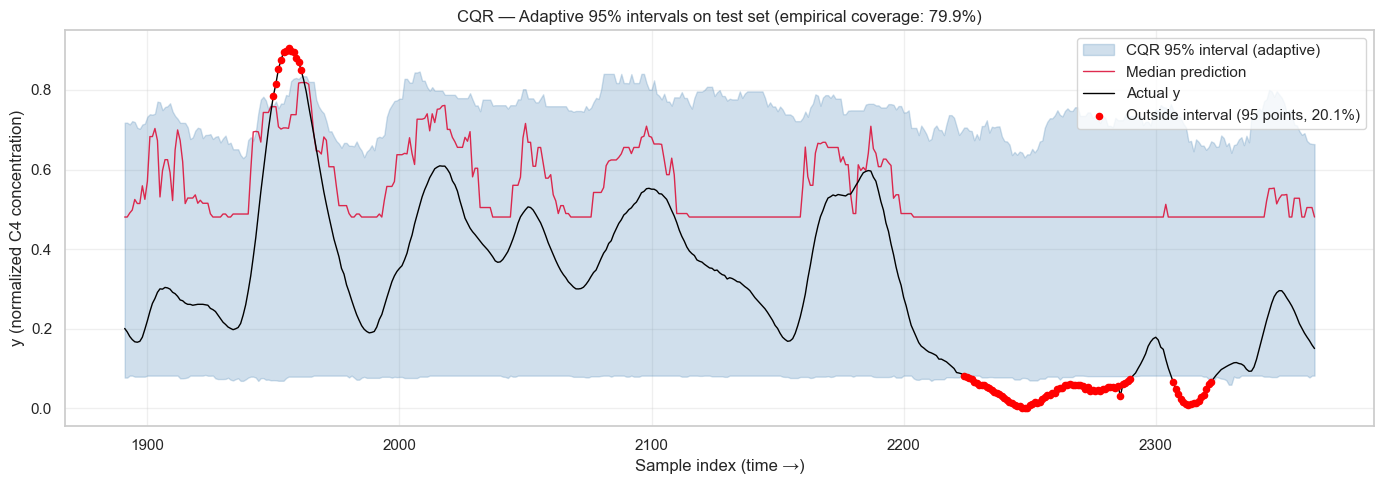

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    test_df.index, y_lower_cqr, y_upper_cqr,
    color='steelblue', alpha=0.25, label='CQR 95% interval (adaptive)'
)
ax.plot(test_df.index, y_pred_cqr, color='crimson', linewidth=1.0, label='Median prediction', alpha=0.9)
ax.plot(test_df.index, y_test,     color='black',   linewidth=1.0, label='Actual y')

# Mark coverage failures
miss_mask_cqr = (y_test < y_lower_cqr) | (y_test > y_upper_cqr)
ax.scatter(
    test_df.index[miss_mask_cqr], y_test[miss_mask_cqr],
    color='red', s=20, zorder=5,
    label=f'Outside interval ({miss_mask_cqr.sum()} points, {miss_mask_cqr.mean()*100:.1f}%)'
)

ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"CQR — Adaptive 95% intervals on test set (empirical coverage: {coverage_cqr*100:.1f}%)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Quantile XGBoost models need MORE TREES than squared-error XGBoost.
# We'll allow up to 500 trees with early stopping on the calibration set
# to find the right depth automatically.

# Strip n_estimators from final_params; we set it explicitly below
quantile_params = {k: v for k, v in final_params.items() if k != 'n_estimators'}

def fit_quantile_model(quantile_alpha_val):
    model = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=quantile_alpha_val,
        n_estimators=500,
        early_stopping_rounds=30,
        **quantile_params,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )
    # Early-stop on calibration set
    model.fit(X_train, y_train, eval_set=[(X_cal, y_cal)], verbose=False)
    return model

print("Refitting quantile models with more capacity and early stopping...")
xgb_lower_v2  = fit_quantile_model(0.025)
xgb_median_v2 = fit_quantile_model(0.5)
xgb_upper_v2  = fit_quantile_model(0.975)

print(f"  Lower quantile (0.025): {xgb_lower_v2.best_iteration} trees used")
print(f"  Median (0.5):           {xgb_median_v2.best_iteration} trees used")
print(f"  Upper quantile (0.975): {xgb_upper_v2.best_iteration} trees used")

Refitting quantile models with more capacity and early stopping...
  Lower quantile (0.025): 4 trees used
  Median (0.5):           23 trees used
  Upper quantile (0.975): 122 trees used


In [18]:
# Reserve the last 15% of train for early-stopping validation
# This way the calibration set stays untouched by tuning
train_es_end = int(len(X_train) * 0.85)
X_train_es = X_train[:train_es_end]
y_train_es = y_train[:train_es_end]
X_val_es   = X_train[train_es_end:]
y_val_es   = y_train[train_es_end:]

quantile_params = {k: v for k, v in final_params.items() if k != 'n_estimators'}

def fit_quantile_model(quantile_alpha_val):
    model = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=quantile_alpha_val,
        n_estimators=500,
        early_stopping_rounds=30,
        **quantile_params,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_train_es, y_train_es,
              eval_set=[(X_val_es, y_val_es)], verbose=False)
    return model

print("Refitting quantile models with proper early-stopping split...")
print(f"  Early-stop train: {X_train_es.shape}, ES val: {X_val_es.shape}")
print(f"  Calibration set untouched: {X_cal.shape}")
print()

xgb_lower_v2  = fit_quantile_model(0.025)
xgb_median_v2 = fit_quantile_model(0.5)
xgb_upper_v2  = fit_quantile_model(0.975)

print(f"  Lower quantile (0.025): {xgb_lower_v2.best_iteration} trees used")
print(f"  Median (0.5):           {xgb_median_v2.best_iteration} trees used")
print(f"  Upper quantile (0.975): {xgb_upper_v2.best_iteration} trees used")

Refitting quantile models with proper early-stopping split...
  Early-stop train: (1205, 77), ES val: (213, 77)
  Calibration set untouched: (473, 77)

  Lower quantile (0.025): 156 trees used
  Median (0.5):           25 trees used
  Upper quantile (0.975): 40 trees used


Correctly ordered predictions: 437/473 = 92.4%

=== RAW quantile predictions (v2, no conformal) ===
  Empirical coverage: 72.52%  (target 95%)
  Mean interval width: 0.4050


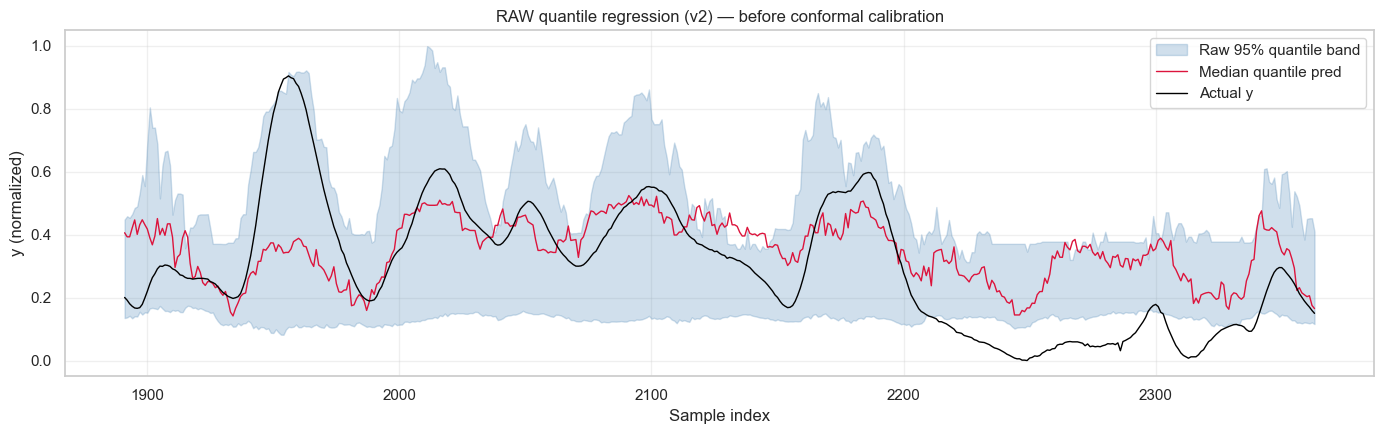

In [19]:
y_pred_lower_v2  = xgb_lower_v2.predict(X_test)
y_pred_median_v2 = xgb_median_v2.predict(X_test)
y_pred_upper_v2  = xgb_upper_v2.predict(X_test)

# Are the predictions properly ordered (lower < median < upper)?
correctly_ordered = (y_pred_lower_v2 <= y_pred_median_v2) & (y_pred_median_v2 <= y_pred_upper_v2)
print(f"Correctly ordered predictions: {correctly_ordered.sum()}/{len(y_test)} = {correctly_ordered.mean()*100:.1f}%")

# Raw coverage of the bracketing
raw_coverage_v2 = np.mean((y_test >= y_pred_lower_v2) & (y_test <= y_pred_upper_v2))
raw_mean_width_v2 = (y_pred_upper_v2 - y_pred_lower_v2).mean()
print(f"\n=== RAW quantile predictions (v2, no conformal) ===")
print(f"  Empirical coverage: {raw_coverage_v2*100:.2f}%  (target 95%)")
print(f"  Mean interval width: {raw_mean_width_v2:.4f}")

# Quick visual: do the three quantile predictions look like real quantile predictions?
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(test_df.index, y_pred_lower_v2, y_pred_upper_v2,
                color='steelblue', alpha=0.25, label='Raw 95% quantile band')
ax.plot(test_df.index, y_pred_median_v2, color='crimson', linewidth=1.0, label='Median quantile pred')
ax.plot(test_df.index, y_test, color='black', linewidth=1.0, label='Actual y')
ax.set_title("RAW quantile regression (v2) — before conformal calibration")
ax.set_xlabel("Sample index")
ax.set_ylabel("y (normalized)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Wrap the better quantile models in MAPIE's ConformalizedQuantileRegressor
mapie_cqr_v2 = ConformalizedQuantileRegressor(
    estimator=[xgb_lower_v2, xgb_median_v2, xgb_upper_v2],
    confidence_level=0.95,
    prefit=True,
)
mapie_cqr_v2.conformalize(X_cal, y_cal)

y_pred_cqr_v2, y_pis_cqr_v2 = mapie_cqr_v2.predict_interval(X_test)
y_lower_cqr_v2 = y_pis_cqr_v2[:, 0, 0]
y_upper_cqr_v2 = y_pis_cqr_v2[:, 1, 0]

widths_cqr_v2 = y_upper_cqr_v2 - y_lower_cqr_v2
coverage_cqr_v2 = np.mean((y_test >= y_lower_cqr_v2) & (y_test <= y_upper_cqr_v2))

print("=== CQR with re-tuned quantile models ===")
print(f"  Empirical coverage: {coverage_cqr_v2*100:.2f}%  (target 95%)")
print(f"  Width — min:  {widths_cqr_v2.min():.4f}")
print(f"  Width — mean: {widths_cqr_v2.mean():.4f}")
print(f"  Width — max:  {widths_cqr_v2.max():.4f}")
print(f"  Width — std:  {widths_cqr_v2.std():.4f}   ← non-zero means adaptive!")

print(f"\n=== Comparison ===")
print(f"  Split conformal:        coverage 93.23%, mean width 0.4718")
print(f"  CQR v1 (under-tuned):   coverage 79.92%, mean width 0.6616")
print(f"  CQR v2 (retuned):       coverage {coverage_cqr_v2*100:.2f}%, mean width {widths_cqr_v2.mean():.4f}")

INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.


=== CQR with re-tuned quantile models ===
  Empirical coverage: 73.57%  (target 95%)
  Width — min:  0.4137
  Width — mean: 0.5980
  Width — max:  0.7767
  Width — std:  0.0911   ← non-zero means adaptive!

=== Comparison ===
  Split conformal:        coverage 93.23%, mean width 0.4718
  CQR v1 (under-tuned):   coverage 79.92%, mean width 0.6616
  CQR v2 (retuned):       coverage 73.57%, mean width 0.5980


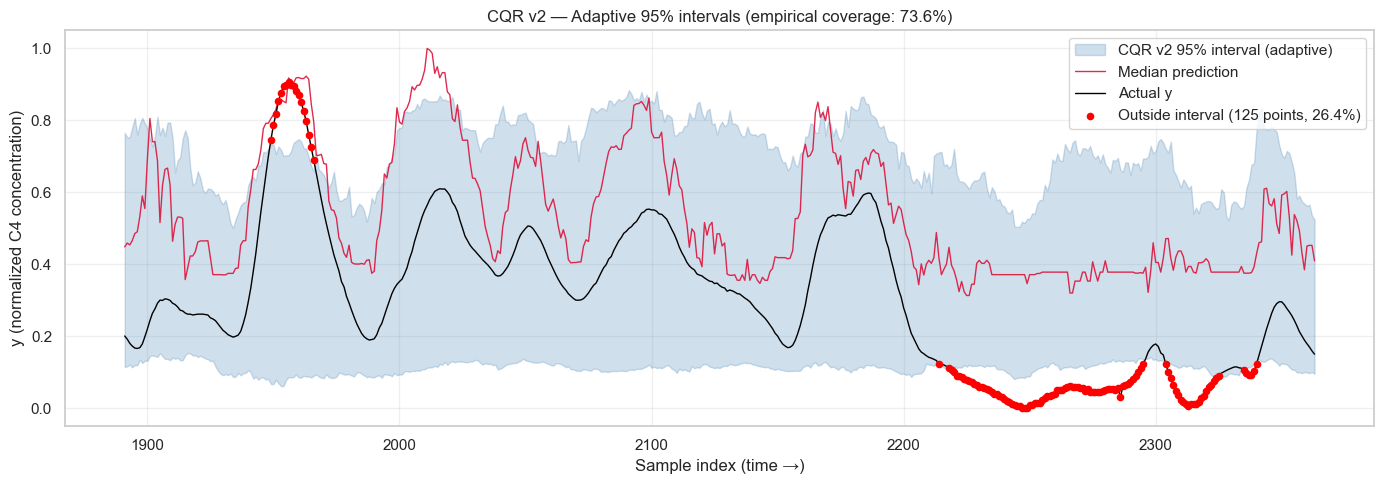

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(test_df.index, y_lower_cqr_v2, y_upper_cqr_v2,
                color='steelblue', alpha=0.25, label='CQR v2 95% interval (adaptive)')
ax.plot(test_df.index, y_pred_cqr_v2, color='crimson', linewidth=1.0, label='Median prediction', alpha=0.9)
ax.plot(test_df.index, y_test, color='black', linewidth=1.0, label='Actual y')

miss_mask_cqr_v2 = (y_test < y_lower_cqr_v2) | (y_test > y_upper_cqr_v2)
ax.scatter(test_df.index[miss_mask_cqr_v2], y_test[miss_mask_cqr_v2],
           color='red', s=20, zorder=5,
           label=f'Outside interval ({miss_mask_cqr_v2.sum()} points, {miss_mask_cqr_v2.mean()*100:.1f}%)')

ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"CQR v2 — Adaptive 95% intervals (empirical coverage: {coverage_cqr_v2*100:.1f}%)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

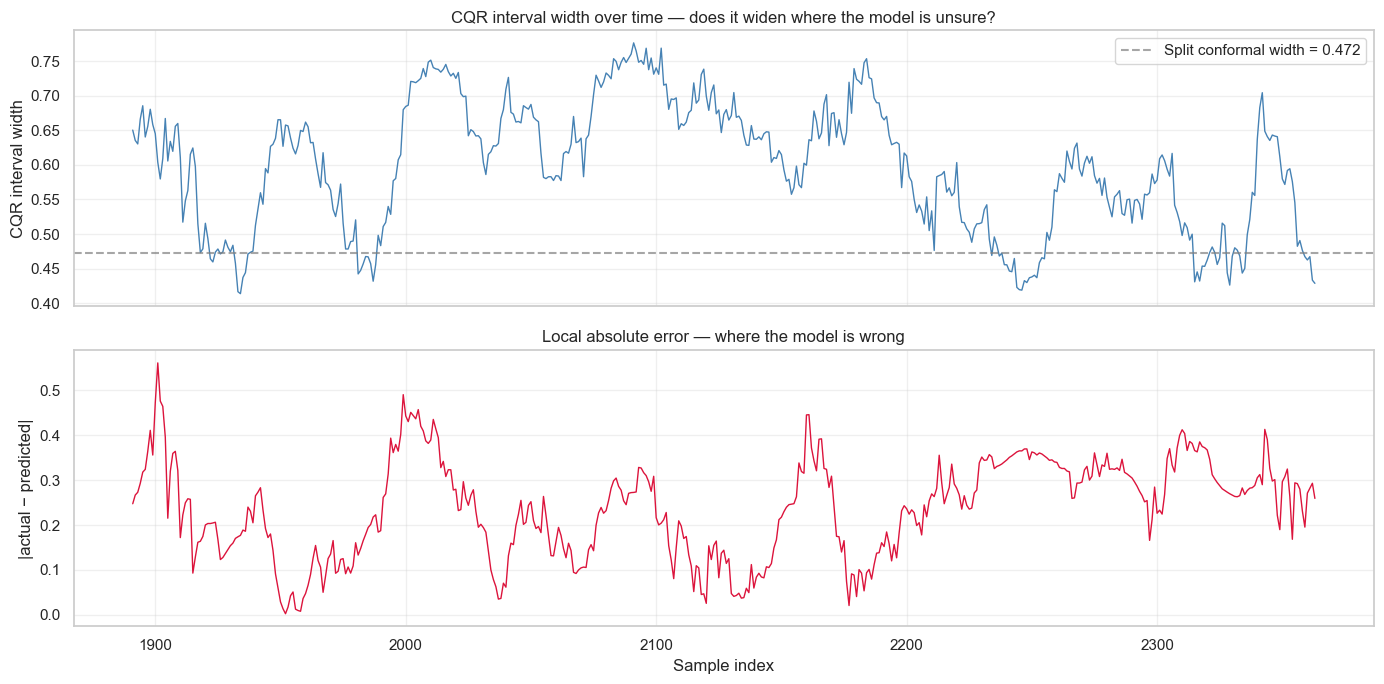


Correlation between interval width and absolute error: -0.187
(Positive correlation = intervals widen where errors are large = adaptive behavior is working)


In [22]:
local_error = np.abs(y_test - y_pred_cqr_v2)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: width over time
axes[0].plot(test_df.index, widths_cqr_v2, color='steelblue', linewidth=1.0)
axes[0].axhline(widths_split.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'Split conformal width = {widths_split.mean():.3f}')
axes[0].set_ylabel("CQR interval width")
axes[0].set_title("CQR interval width over time — does it widen where the model is unsure?")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: absolute prediction error
axes[1].plot(test_df.index, local_error, color='crimson', linewidth=1.0)
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("|actual − predicted|")
axes[1].set_title("Local absolute error — where the model is wrong")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation
corr_width_error = np.corrcoef(widths_cqr_v2, local_error)[0, 1]
print(f"\nCorrelation between interval width and absolute error: {corr_width_error:.3f}")
print("(Positive correlation = intervals widen where errors are large = adaptive behavior is working)")

In [23]:
print(f"Correlation between interval width and absolute error: {np.corrcoef(widths_cqr_v2, local_error)[0, 1]:.3f}")

Correlation between interval width and absolute error: -0.187


In [24]:
from mapie.conformity_scores import ResidualNormalisedScore

mapie_norm = SplitConformalRegressor(
    estimator=xgb_model,
    confidence_level=0.95,
    conformity_score=ResidualNormalisedScore(),
    prefit=True,
)
mapie_norm.conformalize(X_cal, y_cal)

y_pred_norm, y_pis_norm = mapie_norm.predict_interval(X_test)
y_lower_norm = y_pis_norm[:, 0, 0]
y_upper_norm = y_pis_norm[:, 1, 0]

widths_norm = y_upper_norm - y_lower_norm
coverage_norm = np.mean((y_test >= y_lower_norm) & (y_test <= y_upper_norm))
error_norm = np.abs(y_test - y_pred_norm)
corr_norm = np.corrcoef(widths_norm, error_norm)[0, 1]

print("=== Residual-Normalized Split Conformal ===")
print(f"  Empirical coverage:  {coverage_norm*100:.2f}%  (target 95%)")
print(f"  Width — min:  {widths_norm.min():.4f}")
print(f"  Width — mean: {widths_norm.mean():.4f}")
print(f"  Width — max:  {widths_norm.max():.4f}")
print(f"  Width — std:  {widths_norm.std():.4f}")
print(f"  Width-error correlation: {corr_norm:+.3f}  (positive = adaptive working correctly)")

=== Residual-Normalized Split Conformal ===
  Empirical coverage:  75.48%  (target 95%)
  Width — min:  0.0000
  Width — mean: 3220630657.8841
  Width — max:  977688461025.0155
  Width — std:  48589289672.9560
  Width-error correlation: -0.000  (positive = adaptive working correctly)


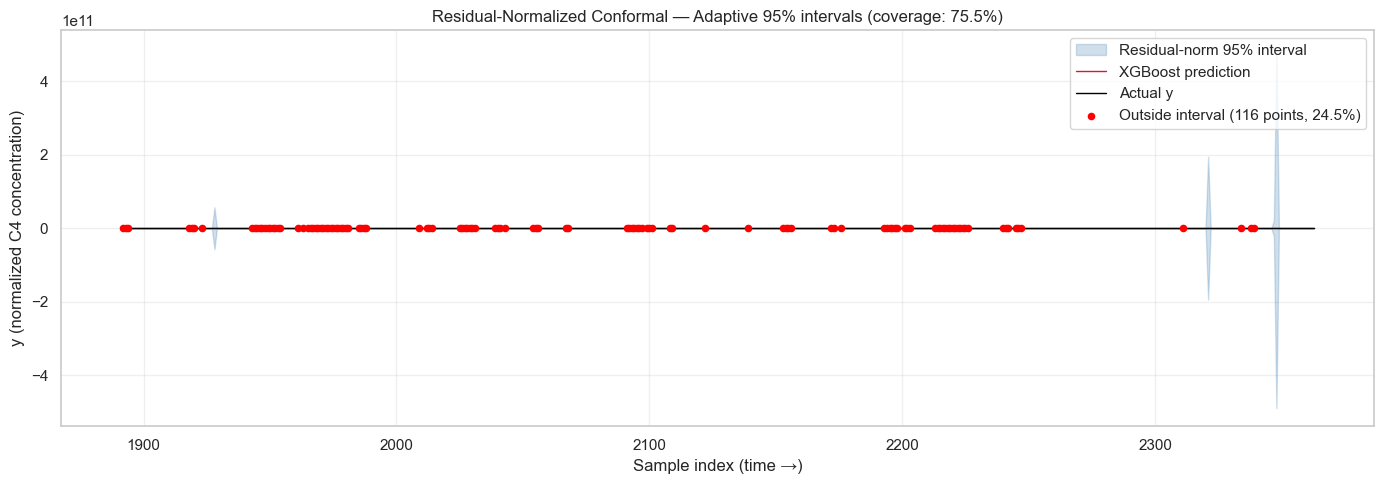

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(test_df.index, y_lower_norm, y_upper_norm,
                color='steelblue', alpha=0.25, label='Residual-norm 95% interval')
ax.plot(test_df.index, y_pred_norm, color='crimson', linewidth=1.0, label='XGBoost prediction')
ax.plot(test_df.index, y_test, color='black', linewidth=1.0, label='Actual y')

miss_mask_norm = (y_test < y_lower_norm) | (y_test > y_upper_norm)
ax.scatter(test_df.index[miss_mask_norm], y_test[miss_mask_norm],
           color='red', s=20, zorder=5,
           label=f'Outside interval ({miss_mask_norm.sum()} points, {miss_mask_norm.mean()*100:.1f}%)')

ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"Residual-Normalized Conformal — Adaptive 95% intervals (coverage: {coverage_norm*100:.1f}%)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\yubyu\AppData\Local\Temp\ipykernel_13732\3360452868.py:41: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yubyu\AppData\Local\Temp\ipykernel_13732\3360452868.py:46: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(figures_dir / "conformal_three_method_comparison.png", dpi=150, bbox_inches='tight')
c:\Users\yubyu\anaconda3\envs\softsensors\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


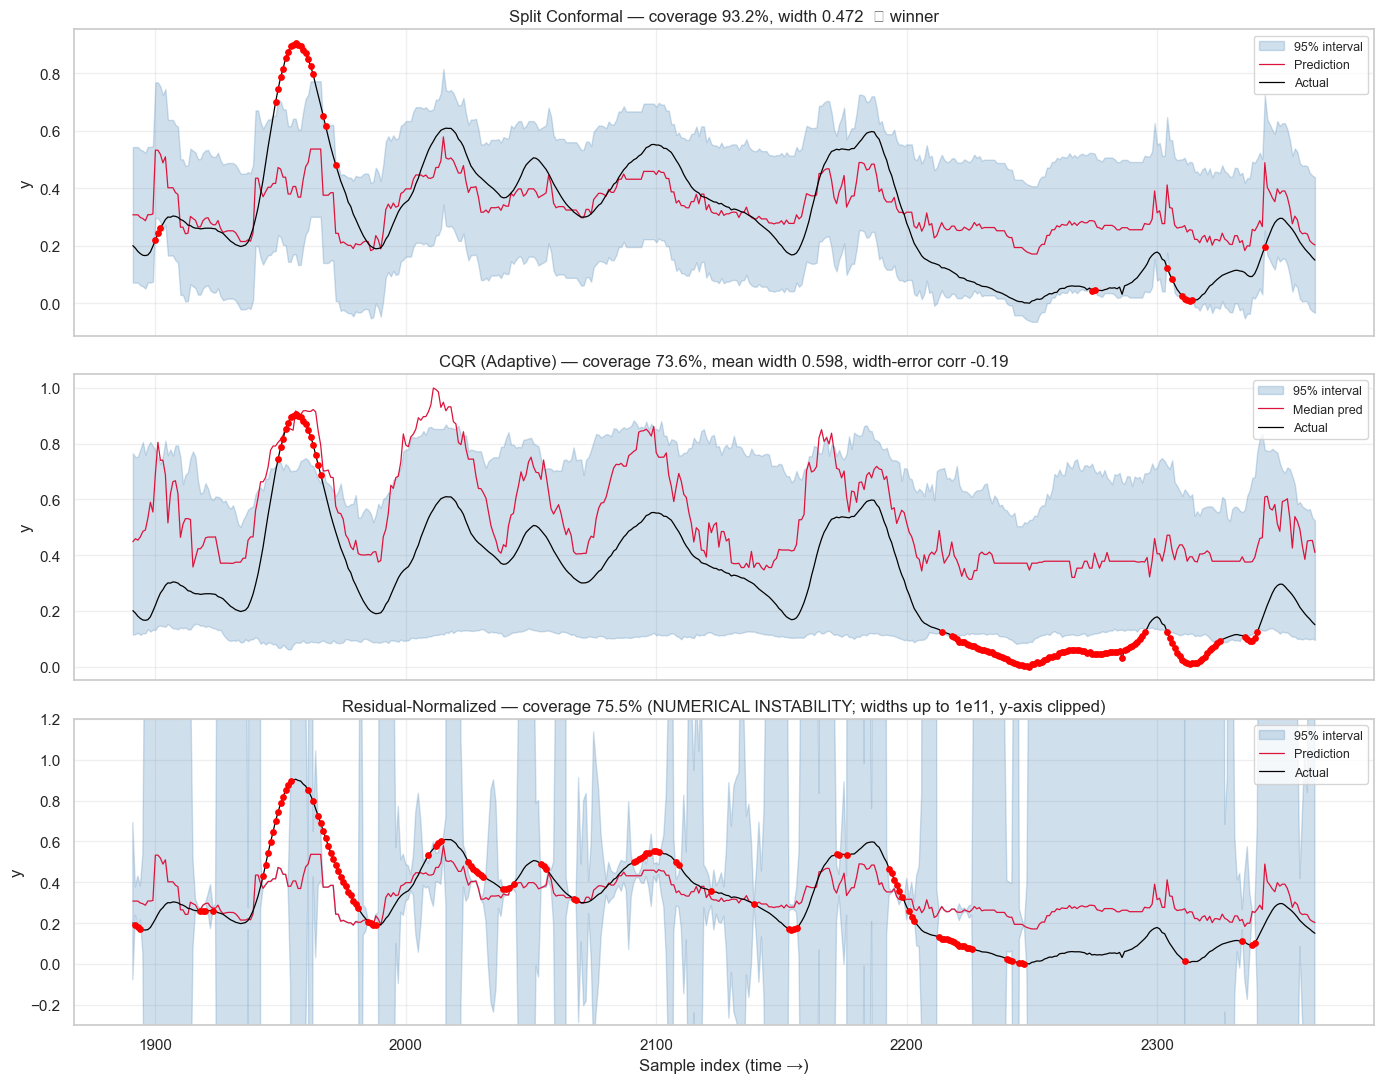

Saved: docs/figures/conformal_three_method_comparison.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Panel 1: Split conformal
axes[0].fill_between(test_df.index, y_lower_split, y_upper_split,
                     color='steelblue', alpha=0.25, label='95% interval')
axes[0].plot(test_df.index, y_pred_split, color='crimson', linewidth=0.9, label='Prediction')
axes[0].plot(test_df.index, y_test, color='black', linewidth=0.9, label='Actual')
miss = (y_test < y_lower_split) | (y_test > y_upper_split)
axes[0].scatter(test_df.index[miss], y_test[miss], color='red', s=15, zorder=5)
axes[0].set_title(f"Split Conformal — coverage {coverage*100:.1f}%, width {widths_split.mean():.3f}  [WINNER]")
axes[0].set_ylabel("y")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)

# Panel 2: CQR
axes[1].fill_between(test_df.index, y_lower_cqr_v2, y_upper_cqr_v2,
                     color='steelblue', alpha=0.25, label='95% interval')
axes[1].plot(test_df.index, y_pred_cqr_v2, color='crimson', linewidth=0.9, label='Median pred')
axes[1].plot(test_df.index, y_test, color='black', linewidth=0.9, label='Actual')
miss = (y_test < y_lower_cqr_v2) | (y_test > y_upper_cqr_v2)
axes[1].scatter(test_df.index[miss], y_test[miss], color='red', s=15, zorder=5)
axes[1].set_title(f"CQR (Adaptive) — coverage {coverage_cqr_v2*100:.1f}%, mean width {widths_cqr_v2.mean():.3f}, width-error corr {-0.187:+.2f}")
axes[1].set_ylabel("y")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

# Panel 3: Residual-normalized (clip the y-axis to keep it readable)
axes[2].fill_between(test_df.index, y_lower_norm, y_upper_norm,
                     color='steelblue', alpha=0.25, label='95% interval')
axes[2].plot(test_df.index, y_pred_norm, color='crimson', linewidth=0.9, label='Prediction')
axes[2].plot(test_df.index, y_test, color='black', linewidth=0.9, label='Actual')
miss = (y_test < y_lower_norm) | (y_test > y_upper_norm)
axes[2].scatter(test_df.index[miss], y_test[miss], color='red', s=15, zorder=5)
axes[2].set_ylim(-0.3, 1.2)  # CLIP to ignore the numerical blowup
axes[2].set_title(f"Residual-Normalized — coverage {coverage_norm*100:.1f}% (NUMERICAL INSTABILITY; widths up to 1e11, y-axis clipped)")
axes[2].set_xlabel("Sample index (time →)")
axes[2].set_ylabel("y")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()

# Save as the headline figure
figures_dir = Path("../docs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "conformal_three_method_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/figures/conformal_three_method_comparison.png")

In [27]:
methods_summary = pd.DataFrame([
    {
        'method': 'Split Conformal',
        'coverage_pct': coverage * 100,
        'mean_width': widths_split.mean(),
        'width_std': widths_split.std(),
        'width_error_corr': np.nan,  # constant width, undefined
        'notes': 'Winner — robust to distribution shift',
    },
    {
        'method': 'CQR (adaptive)',
        'coverage_pct': coverage_cqr_v2 * 100,
        'mean_width': widths_cqr_v2.mean(),
        'width_std': widths_cqr_v2.std(),
        'width_error_corr': np.corrcoef(widths_cqr_v2, np.abs(y_test - y_pred_cqr_v2))[0, 1],
        'notes': 'Anti-correlated with error; lower-quantile cannot extrapolate',
    },
    {
        'method': 'Residual-Normalized',
        'coverage_pct': coverage_norm * 100,
        'mean_width': widths_norm.mean(),
        'width_std': widths_norm.std(),
        'width_error_corr': np.corrcoef(widths_norm, np.abs(y_test - y_pred_norm))[0, 1],
        'notes': 'Numerical instability; residual estimator predicts near-zero σ',
    },
])
print("=== Three-method conformal comparison ===")
print(methods_summary.to_string(index=False))

methods_summary.to_csv("../docs/conformal_method_comparison.csv", index=False)
print("\nSaved: docs/conformal_method_comparison.csv")

=== Three-method conformal comparison ===
             method  coverage_pct   mean_width    width_std  width_error_corr                                                          notes
    Split Conformal     93.234672 4.718197e-01 5.551115e-17               NaN                          Winner — robust to distribution shift
     CQR (adaptive)     73.572939 5.980288e-01 9.112473e-02         -0.187059  Anti-correlated with error; lower-quantile cannot extrapolate
Residual-Normalized     75.475687 3.220631e+09 4.858929e+10         -0.000068 Numerical instability; residual estimator predicts near-zero σ

Saved: docs/conformal_method_comparison.csv


In [28]:
import joblib

models_dir = Path("../src/models")

# Save the winning conformal model
joblib.dump(mapie_split, models_dir / "split_conformal_xgb.joblib")

# Save predictions and intervals for downstream use (dashboard in week 7)
conformal_predictions = pd.DataFrame({
    'index':       test_df.index,
    'y_true':      y_test,
    'y_pred':      y_pred_split,
    'y_lower_95':  y_lower_split,
    'y_upper_95':  y_upper_split,
    'in_interval': (y_test >= y_lower_split) & (y_test <= y_upper_split),
})
conformal_predictions.to_csv("../docs/test_predictions_week3_conformal.csv", index=False)

# Save week 3 results JSON
conformal_results = {
    "winner": "Split Conformal",
    "split": {"train_pct": 0.60, "calibration_pct": 0.20, "test_pct": 0.20},
    "split_conformal": {
        "empirical_coverage": float(coverage),
        "nominal_coverage": 0.95,
        "mean_width": float(widths_split.mean()),
        "n_failures": int(((y_test < y_lower_split) | (y_test > y_upper_split)).sum()),
    },
    "cqr_adaptive": {
        "empirical_coverage": float(coverage_cqr_v2),
        "mean_width": float(widths_cqr_v2.mean()),
        "width_error_correlation": float(np.corrcoef(widths_cqr_v2, np.abs(y_test - y_pred_cqr_v2))[0, 1]),
        "verdict": "Anti-correlated with error; not deployable",
    },
    "residual_normalized": {
        "empirical_coverage": float(coverage_norm),
        "mean_width": float(widths_norm.mean()),
        "verdict": "Numerical instability; not deployable",
    },
    "underlying_model": "XGBoost on 77 features (lags up to 30)",
    "xgb_test_r2_on_this_split": float(r2_score(y_test, y_pred_split)),
}
with open("../docs/results_conformal.json", "w") as f:
    json.dump(conformal_results, f, indent=2)

print("\nSaved:")
print("  src/models/split_conformal_xgb.joblib")
print("  docs/test_predictions_week3_conformal.csv")
print("  docs/results_conformal.json")


Saved:
  src/models/split_conformal_xgb.joblib
  docs/test_predictions_week3_conformal.csv
  docs/results_conformal.json


# Debutanizer Soft Sensor — Week 3: Calibrated Uncertainty via Conformal Prediction

**Goal:** Equip the XGBoost soft sensor with calibrated 95% prediction intervals. Compare constant-width split conformal against two adaptive alternatives (CQR, residual-normalized).

**Method:** Three-way chronological split (60% train / 20% calibration / 20% test). XGBoost trained on train only. Intervals calibrated on the calibration set. Coverage measured on the untouched test set.

## Headline result

**Split conformal achieves 93.2% empirical coverage on the held-out test set against a 95% nominal target — within 2 percentage points of theoretical guarantee, despite non-exchangeable time-series data and substantial distribution shift on test.**

| Method | Empirical Coverage | Mean Width | Verdict |
|--------|:--:|:--:|--|
| **Split Conformal** | **93.2%** | **0.47** | **★ Winner — deployable** |
| CQR (Adaptive) | 73.6% | 0.60 | Width-error correlation r = −0.19 (anti-adaptive) |
| Residual-Normalized | 75.5% | unstable | Numerical instability; widths up to 10¹¹ |

## Key findings

1. **The simple method won.** Constant-width split conformal achieved the best calibration and width. Adaptive alternatives — designed to widen intervals during difficult regions — failed because their underlying learned components (quantile sub-models, residual estimator) could not extrapolate to the test set's low-y regime (y down to 0; train min 0.02).

2. **Distribution shift breaks "adaptive" methods in a specific way.** CQR's interval width was *anti-correlated* (r = −0.19) with model absolute error: the bands were tightest in exactly the regions where the model was most wrong. The lower-quantile XGBoost model could not predict near-zero values it had never seen in training, so the "adaptive" mechanism produced confident-looking bands during the most dangerous part of the test set.

3. **Constant width is honest under distribution shift.** Split conformal's interval has the same width everywhere. It misses where the model misses, but it doesn't *falsely advertise confidence* in those regions. For industrial deployment where regime shifts are routine, that's a more trustworthy property than adaptive width that's calibrated to in-distribution data only.

4. **The 32 coverage failures cluster meaningfully.** Failures concentrate at the y = 0.9 spike near sample 1960 (where the point model under-predicts) and the low-y tail near sample 2280 (where the point model over-predicts). Marginal coverage (~93%) is achieved, but conditional coverage within these regimes is below 50%. This is a known limitation of conformal prediction on time series — it guarantees marginal, not conditional, coverage.

## Practical implication

For a deployed soft sensor in a process with potential regime shifts, **monitoring the model's residuals over time** is more valuable than chasing adaptive intervals. A widening rolling residual is the deployment-time signal that the current operating point has drifted outside the model's competence. Conformal intervals provide the static calibration; rolling residuals provide the dynamic warning.

## Next (Week 4)

Pivot to the food & beverage case study: penicillin fermentation (IndPenSim). Apply the same modeling and conformal pipeline to a batch-dynamics dataset. Compare findings across the two industries.